# Rabi Gurung
# 2026 Summer - Advanced Big Data and Data Mining (MSCS-634-B01)
# Lab 4: Regression Analysis with Regularization Techniques

This notebook uses the Diabetes dataset from `sklearn.datasets` to compare simple linear regression, multiple regression, polynomial regression, Ridge regression, and Lasso regression. The goal is to see how each model predicts disease progression and how regularization changes model performance.

## Step 1: Data Preparation

First I load the Diabetes dataset, put it into a pandas DataFrame, and check the shape, feature names, target values, missing values, and summary statistics. This helps me understand the data before fitting any model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

RANDOM_STATE = 42
plt.style.use('default')

diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name='disease_progression')

df = X.copy()
df['disease_progression'] = y

print('Dataset shape:', df.shape)
print('Feature names:', list(X.columns))
print('\nMissing values:')
print(df.isna().sum())
print('\nFirst five rows:')
display(df.head())
print('\nSummary statistics:')
display(df.describe().T)

Matplotlib is building the font cache; this may take a moment.


Dataset shape: (442, 11)
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Missing values:
age                    0
sex                    0
bmi                    0
bp                     0
s1                     0
s2                     0
s3                     0
s4                     0
s5                     0
s6                     0
disease_progression    0
dtype: int64

First five rows:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,disease_progression
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0



Summary statistics:


,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.268604e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


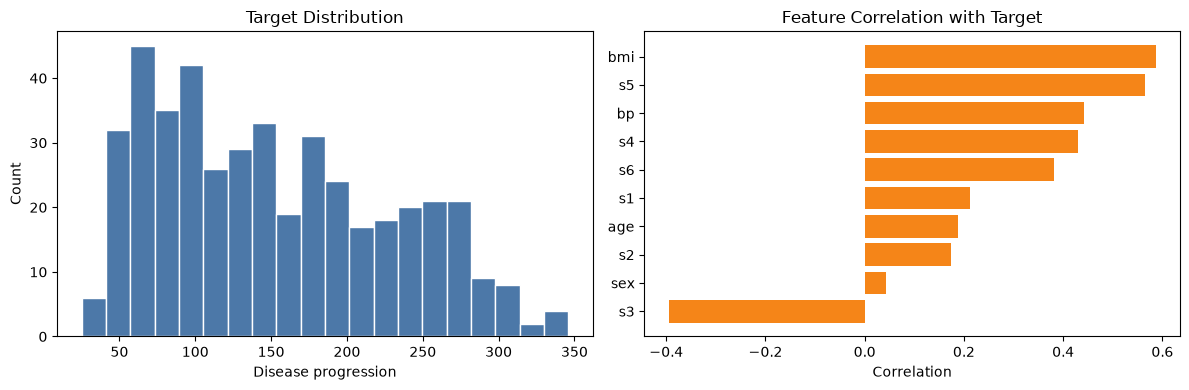

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y, bins=20, color='#4C78A8', edgecolor='white')
axes[0].set_title('Target Distribution')
axes[0].set_xlabel('Disease progression')
axes[0].set_ylabel('Count')

corr_with_target = df.corr(numeric_only=True)['disease_progression'].drop('disease_progression').sort_values()
axes[1].barh(corr_with_target.index, corr_with_target.values, color='#F58518')
axes[1].set_title('Feature Correlation with Target')
axes[1].set_xlabel('Correlation')
plt.tight_layout()
plt.show()

There are 442 rows and 10 feature columns. The missing value check shows that the dataset is already clean, so I do not need to drop or fill any values. The target distribution is spread across low and high disease progression values, which means the model needs to learn a continuous prediction rather than a category. The BMI feature has one of the stronger positive relationships with the target, so I use BMI for the simple linear regression model.

In [3]:
def regression_metrics(model_name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        'Model': model_name,
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'R2': r2_score(y_true, y_pred)
    }

metrics = []

## Step 2: Simple Linear Regression

For the simple linear regression model, I use BMI as the independent variable because it has a clear positive relationship with the target. I split the data into training and testing sets, train the model, evaluate it, and plot the prediction line against the actual test data.

Simple linear regression coefficient: 998.5776891375593
Simple linear regression intercept: 152.00335421448167


,Model,MAE,MSE,RMSE,R2
0,Simple Linear Regression (BMI),52.259976,4061.825928,63.732456,0.23335


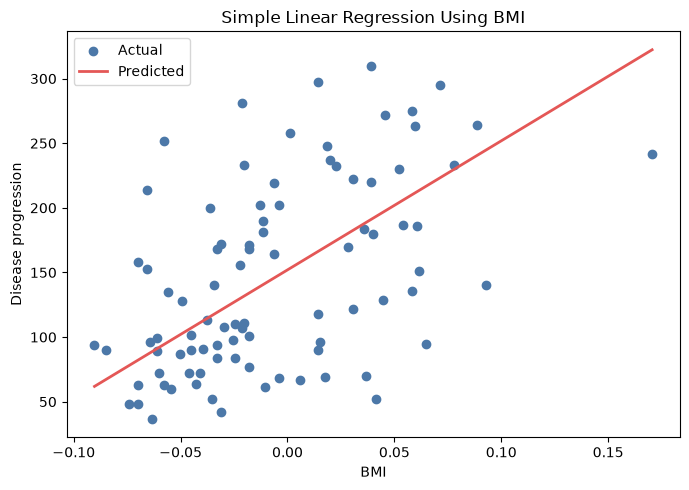

In [4]:
X_simple = X[['bmi']]
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=RANDOM_STATE
)

simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_s)
y_pred_simple = simple_model.predict(X_test_s)
metrics.append(regression_metrics('Simple Linear Regression (BMI)', y_test_s, y_pred_simple))

print('Simple linear regression coefficient:', simple_model.coef_[0])
print('Simple linear regression intercept:', simple_model.intercept_)
display(pd.DataFrame([metrics[-1]]))

plt.figure(figsize=(7, 5))
plt.scatter(X_test_s['bmi'], y_test_s, color='#4C78A8', label='Actual')
order = np.argsort(X_test_s['bmi'].values)
plt.plot(X_test_s['bmi'].values[order], y_pred_simple[order], color='#E45756', linewidth=2, label='Predicted')
plt.title('Simple Linear Regression Using BMI')
plt.xlabel('BMI')
plt.ylabel('Disease progression')
plt.legend()
plt.tight_layout()
plt.show()

## Step 3: Multiple Regression

The multiple regression model uses all 10 independent variables. This should give the model more information than BMI alone, but it can also become more sensitive to noise if some features do not add much useful signal.

,Model,MAE,MSE,RMSE,R2
0,Multiple Linear Regression,42.794095,2900.193628,53.853446,0.452603


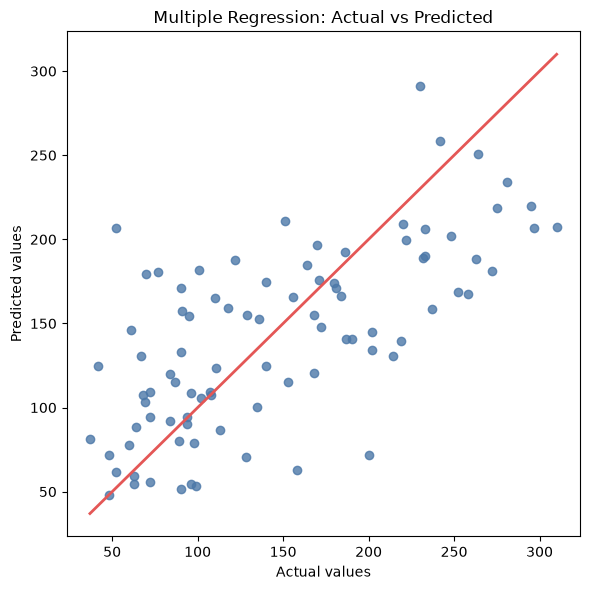

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

multiple_model = LinearRegression()
multiple_model.fit(X_train, y_train)
y_pred_multiple = multiple_model.predict(X_test)
metrics.append(regression_metrics('Multiple Linear Regression', y_test, y_pred_multiple))

display(pd.DataFrame([metrics[-1]]))

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_multiple, color='#4C78A8', alpha=0.8)
lims = [min(y_test.min(), y_pred_multiple.min()), max(y_test.max(), y_pred_multiple.max())]
plt.plot(lims, lims, color='#E45756', linewidth=2)
plt.title('Multiple Regression: Actual vs Predicted')
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.tight_layout()
plt.show()

## Step 4: Polynomial Regression

Polynomial regression adds curved terms to the model. I test degrees 2, 3, and 5 so I can compare underfitting and overfitting. A higher degree can fit the training data more closely, but that does not always mean it predicts new data better.

,Model,MAE,MSE,RMSE,R2,Train R2
0,Polynomial Regression degree 2,43.581693,3096.028307,55.641965,0.415640,0.606158
1,Polynomial Regression degree 3,161.189564,77808.801581,278.942291,-13.686027,0.876637
2,Polynomial Regression degree 5,182.602896,68178.084399,261.109334,-11.868277,1.000000


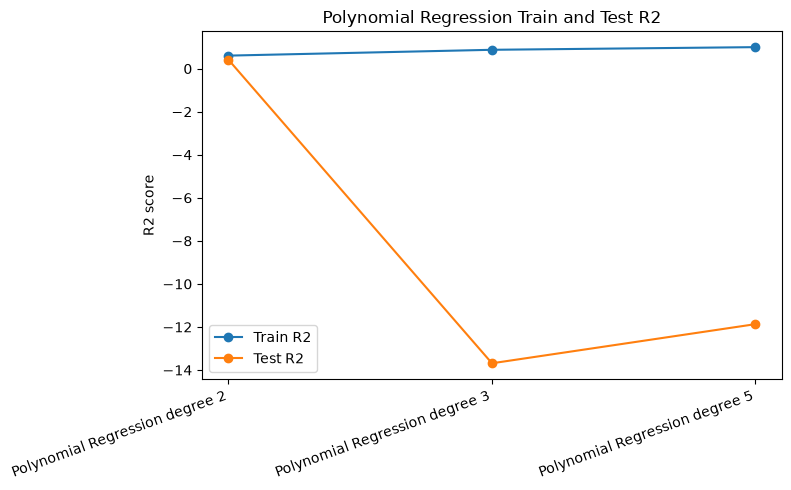

In [6]:
poly_results = []
for degree in [2, 3, 5]:
    poly_model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        StandardScaler(),
        LinearRegression()
    )
    poly_model.fit(X_train, y_train)
    train_pred = poly_model.predict(X_train)
    test_pred = poly_model.predict(X_test)
    row = regression_metrics(f'Polynomial Regression degree {degree}', y_test, test_pred)
    row['Train R2'] = r2_score(y_train, train_pred)
    poly_results.append(row)
    metrics.append({k: row[k] for k in ['Model', 'MAE', 'MSE', 'RMSE', 'R2']})

poly_df = pd.DataFrame(poly_results)
display(poly_df)

plt.figure(figsize=(8, 5))
plt.plot(poly_df['Model'], poly_df['Train R2'], marker='o', label='Train R2')
plt.plot(poly_df['Model'], poly_df['R2'], marker='o', label='Test R2')
plt.xticks(rotation=20, ha='right')
plt.title('Polynomial Regression Train and Test R2')
plt.ylabel('R2 score')
plt.legend()
plt.tight_layout()
plt.show()

The polynomial models show why a more complex model is not always better. When the degree increases, the training score can improve because the model has more flexibility. The test score does not improve in the same way, and this is a sign of overfitting. The model starts learning patterns that are too specific to the training set instead of learning a pattern that works well on new data.

## Step 5: Ridge and Lasso Regression

Ridge and Lasso regression use alpha values to control regularization strength. A small alpha behaves more like ordinary linear regression. A larger alpha shrinks coefficients more. Ridge usually keeps all features but makes their coefficients smaller, while Lasso can shrink some coefficients all the way to zero.

,Model,MAE,MSE,RMSE,R2,Nonzero Coefficients
0,Ridge alpha 0.01,42.794171,2900.075130,53.852346,0.452625,10
1,Lasso alpha 0.01,42.795018,2898.368019,53.836493,0.452947,10
2,Ridge alpha 0.1,42.796235,2899.054556,53.842869,0.452818,10
3,Lasso alpha 0.1,42.805234,2884.624289,53.708698,0.455541,10
4,Ridge alpha 1.0,42.811999,2892.014566,53.777454,0.454147,10
5,Lasso alpha 1.0,42.802984,2824.568094,53.146666,0.466877,9
6,Ridge alpha 10.0,42.856825,2875.778718,53.626288,0.457211,10
7,Lasso alpha 10.0,44.764599,2933.834730,54.164885,0.446253,4


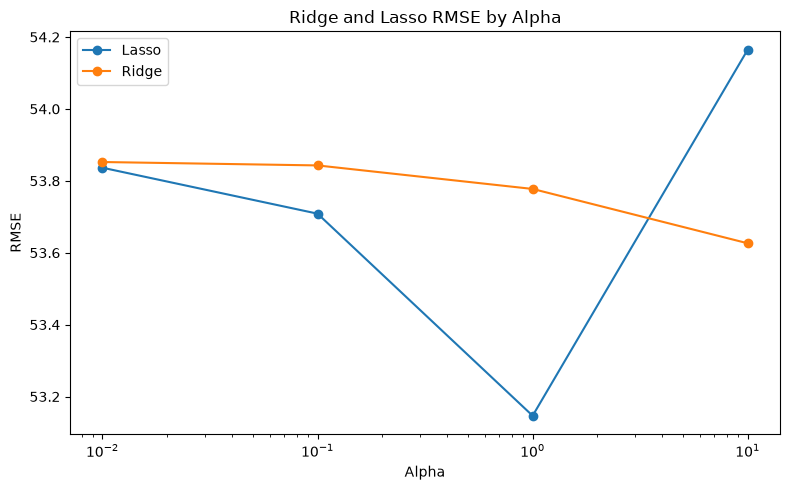

In [7]:
regularization_rows = []
for alpha in [0.01, 0.1, 1.0, 10.0]:
    ridge_model = make_pipeline(StandardScaler(), Ridge(alpha=alpha, random_state=RANDOM_STATE))
    lasso_model = make_pipeline(StandardScaler(), Lasso(alpha=alpha, max_iter=10000, random_state=RANDOM_STATE))
    
    for model_name, model in [('Ridge', ridge_model), ('Lasso', lasso_model)]:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        row = regression_metrics(f'{model_name} alpha {alpha}', y_test, preds)
        estimator = model.named_steps[model_name.lower()]
        row['Nonzero Coefficients'] = int(np.sum(np.abs(estimator.coef_) > 1e-8))
        regularization_rows.append(row)

regularization_df = pd.DataFrame(regularization_rows)
display(regularization_df)

best_ridge = regularization_df[regularization_df['Model'].str.startswith('Ridge')].sort_values('RMSE').iloc[0]
best_lasso = regularization_df[regularization_df['Model'].str.startswith('Lasso')].sort_values('RMSE').iloc[0]
metrics.append(best_ridge[['Model', 'MAE', 'MSE', 'RMSE', 'R2']].to_dict())
metrics.append(best_lasso[['Model', 'MAE', 'MSE', 'RMSE', 'R2']].to_dict())

plt.figure(figsize=(8, 5))
for label, group in regularization_df.assign(Type=regularization_df['Model'].str.split().str[0]).groupby('Type'):
    plt.plot(group['Model'].str.extract(r'alpha (.*)')[0].astype(float), group['RMSE'], marker='o', label=label)
plt.xscale('log')
plt.title('Ridge and Lasso RMSE by Alpha')
plt.xlabel('Alpha')
plt.ylabel('RMSE')
plt.legend()
plt.tight_layout()
plt.show()

,Feature,Ridge Coefficient,Lasso Coefficient
0,age,1.931332,0.687032
1,sex,-11.028192,-9.297519
2,bmi,25.605561,26.219225
3,bp,16.304191,15.657314
4,s1,-12.934236,-8.228172
5,s2,0.538173,-0.000000
6,s3,-6.125109,-9.024087
7,s4,8.569484,3.420861
8,s5,22.749308,22.636465
9,s6,2.918146,2.098647


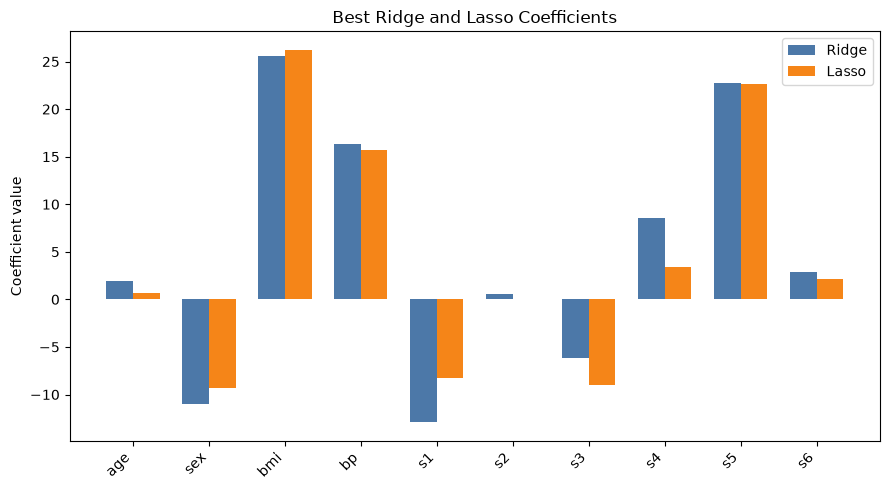

In [8]:
best_ridge_model = make_pipeline(StandardScaler(), Ridge(alpha=float(best_ridge['Model'].split()[-1]), random_state=RANDOM_STATE))
best_lasso_model = make_pipeline(StandardScaler(), Lasso(alpha=float(best_lasso['Model'].split()[-1]), max_iter=10000, random_state=RANDOM_STATE))
best_ridge_model.fit(X_train, y_train)
best_lasso_model.fit(X_train, y_train)

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Ridge Coefficient': best_ridge_model.named_steps['ridge'].coef_,
    'Lasso Coefficient': best_lasso_model.named_steps['lasso'].coef_
})
display(coef_df)

plt.figure(figsize=(9, 5))
width = 0.35
positions = np.arange(len(coef_df))
plt.bar(positions - width/2, coef_df['Ridge Coefficient'], width, label='Ridge', color='#4C78A8')
plt.bar(positions + width/2, coef_df['Lasso Coefficient'], width, label='Lasso', color='#F58518')
plt.xticks(positions, coef_df['Feature'], rotation=45, ha='right')
plt.title('Best Ridge and Lasso Coefficients')
plt.ylabel('Coefficient value')
plt.legend()
plt.tight_layout()
plt.show()

## Step 6: Model Comparison and Analysis

This final section compares all models using the same evaluation metrics. Lower MAE, MSE, and RMSE are better, while a higher R2 score is better. I use this table to decide which model performed best on the test set.

,Model,MAE,MSE,RMSE,R2
6,Lasso alpha 1.0,42.802984,2824.568094,53.146666,0.466877
5,Ridge alpha 10.0,42.856825,2875.778718,53.626288,0.457211
1,Multiple Linear Regression,42.794095,2900.193628,53.853446,0.452603
2,Polynomial Regression degree 2,43.581693,3096.028307,55.641965,0.415640
0,Simple Linear Regression (BMI),52.259976,4061.825928,63.732456,0.233350
4,Polynomial Regression degree 5,182.602896,68178.084399,261.109334,-11.868277
3,Polynomial Regression degree 3,161.189564,77808.801581,278.942291,-13.686027


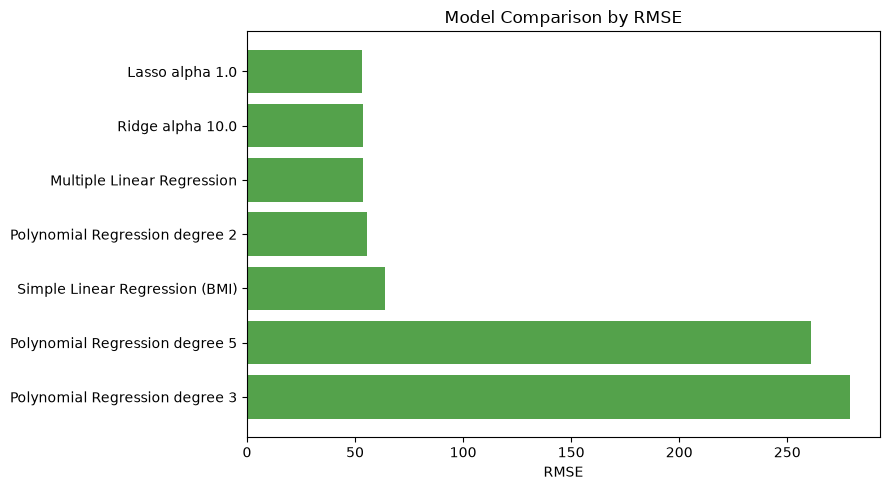

Best model by RMSE: Lasso alpha 1.0


In [9]:
comparison_df = pd.DataFrame(metrics).drop_duplicates(subset=['Model']).reset_index(drop=True)
comparison_df = comparison_df.sort_values('RMSE')
display(comparison_df)

plt.figure(figsize=(9, 5))
plt.barh(comparison_df['Model'], comparison_df['RMSE'], color='#54A24B')
plt.gca().invert_yaxis()
plt.title('Model Comparison by RMSE')
plt.xlabel('RMSE')
plt.tight_layout()
plt.show()

print('Best model by RMSE:', comparison_df.iloc[0]['Model'])

The comparison shows that using all features performs better than using BMI alone. This makes sense because disease progression is connected to several measurements, not only one measurement. The polynomial models also show the danger of adding too much complexity. Some polynomial settings can fit the training data more closely, but their test results are weaker, so they do not generalize well. Ridge and Lasso help control this problem by shrinking coefficients. In this run, the best regularized model is close to the multiple regression model, which means regularization helped keep the model stable without changing the prediction task too much. Lasso is also useful because it can reduce some coefficients to zero, making the model simpler to read. Overall, the Diabetes dataset shows that regression models need to balance prediction accuracy with model complexity.